# TIPE


## Importations

In [1]:
import os
import uuid
import cv2
from PIL import Image, ImageDraw

## Chargement de toutes les données collectées

In [2]:
import tensorflow as tf
import json
import numpy as np
import matplotlib.pyplot as plt

In [3]:
images = tf.data.Dataset.list_files('data\\extracted\\*.jpg', shuffle=False)

In [4]:
def load_image(x):
    byte_img = tf.io.read_file(x)
    img = tf.io.decode_jpeg(byte_img)
    return img

def load_im_mask(x):
    byte_img = tf.io.read_file(x)
    img = tf.io.decode_png(byte_img)
    return img

In [5]:
images = images.map(load_image)

In [6]:
# images.as_numpy_iterator().next()

In [7]:
image_generator = images.batch(4).as_numpy_iterator()

In [8]:
plot_images = image_generator.next()

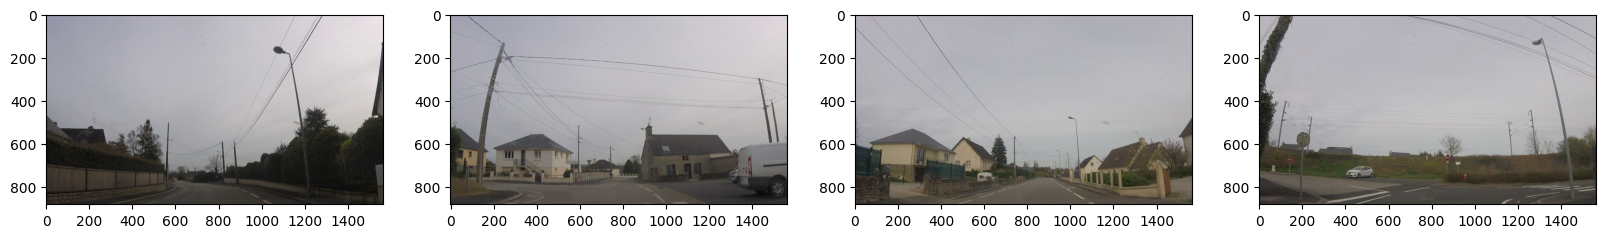

In [9]:
fig, ax = plt.subplots(ncols=4, figsize=(20,20))
for idx, image in enumerate(plot_images):
    ax[idx].imshow(image)
plt.show()

## Séparation des données

In [ ]:
# Here split images into three folders: train / test / val
# Need enough amount of images
# 70% for train, 15% for each test and val

In [10]:
for folder in  ['train', 'test', 'val']:
    for file in os.listdir(os.path.join('data', 'images', folder)):
        filename = file.split('.')[0]+'.png'
        existing_filepath = os.path.join('data', 'masks', filename)
        if os.path.exists(existing_filepath):
            new_filepath = os.path.join('data','images', folder + "_masks", filename)
            os.replace(existing_filepath, new_filepath)

## Génération des plus de données à partir de celles existantes

In [11]:
import albumentations as alb

In [300]:
augmentor = alb.Compose([alb.CropNonEmptyMaskIfExists(width=750, height=421), alb.HorizontalFlip(p=0.5), alb.RandomBrightnessContrast(p=0.2), alb.RandomGamma(p=0.2)])

In [367]:
image = plt.imread(os.path.join('data', 'images', "train",'a0b9f304-d6ed-11ed-bd4d-b808cfebfb26.jpg'))
mask = plt.imread(os.path.join('data', 'images', "train_masks", 'a0b9f304-d6ed-11ed-bd4d-b808cfebfb26.png'))

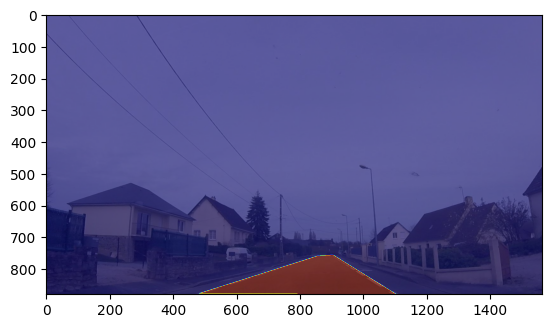

In [368]:
plt.imshow(image)
plt.imshow(mask, cmap='jet', alpha=0.5)

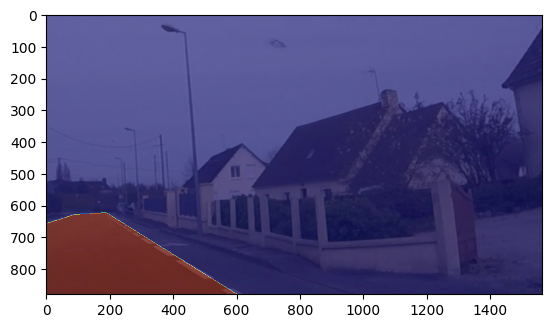

In [369]:
transformed = augmentor(image=image, mask=mask)
newim=cv2.resize(transformed['image'], dsize=(1564,880))
newmask=cv2.resize(transformed['mask'], dsize=(1564,880))
plt.imshow(newim)
plt.imshow(newmask.astype(int), cmap='jet', alpha=0.5)
# plt.imsave('test.png', newmask, cmap='gray')
Image.fromarray(mask.astype("b1")).save("test.png")

In [365]:
# for file in os.listdir(os.path.join('data', 'images')):
#     filename = file.split('.')[0]
#     image = plt.imread(os.path.join('data', 'images', file))
#     mask = plt.imread(os.path.join('data', 'masks', filename+'.png'))
#     for i in range(500):
#         transformed = augmentor(image=image, mask=mask)
#         plt.imsave(os.path.join('data', 'images', filename+ '.' + str(i) +'.jpg'), transformed['image'])
#         plt.imsave(os.path.join('data', 'masks', filename+'.' + str(i) +'.png'), transformed['mask'], cmap='gray')

for folder in  ['train', 'test', 'val']:        
    for file in os.listdir(os.path.join('data', 'images', folder)):
        filename = file.split('.')[0]
        image = plt.imread(os.path.join("data", "images", folder, file))
        mask = plt.imread(os.path.join('data', 'images', folder+"_masks", filename+".png"))
        for i in range(10):
            transformed = augmentor(image=image, mask=mask)
            plt.imsave(os.path.join('data', 'images', folder ,filename+ '.' + str(i) +'.jpg'), transformed['image'])
            Image.fromarray(transformed['mask'].astype("b1")).save(os.path.join('data', 'images', folder+"_masks", filename+'.' + str(i) +'.png'))

## Jeux de données

In [370]:
train_images = tf.data.Dataset.list_files('data\\images\\train\\*.jpg', shuffle=False)
train_images = train_images.map(load_image)
train_images = train_images.map(lambda x: tf.image.resize(x, (104,184)))
train_images = train_images.map(lambda x: x/255)

In [371]:
val_images = tf.data.Dataset.list_files('data\\images\\val\\*.jpg', shuffle=False)
val_images = val_images.map(load_image)
val_images = val_images.map(lambda x: tf.image.resize(x, (104,184)))
val_images = val_images.map(lambda x: x/255)

In [372]:
test_images = tf.data.Dataset.list_files('data\\images\\test\\*.jpg', shuffle=False)
test_images = test_images.map(load_image)
test_images = test_images.map(lambda x: tf.image.resize(x, (104,184)))
test_images = test_images.map(lambda x: x/255)

In [374]:
def load_masks (img) :
    ret= np.zeros((img.shape[0], img.shape[1]))
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            if img[i,j,0] == 1:
                ret[i,j] = 1
    return ret

In [375]:
train_masks = tf.data.Dataset.list_files('data\\images\\train_masks\\*.png', shuffle=False)
train_masks = train_masks.map(load_im_mask)
# train_masks = train_masks.map(lambda x: tf.image.rgb_to_grayscale(x))
train_masks = train_masks.map(lambda x: tf.image.resize(x, (104,184)))
train_masks = train_masks.map(lambda x: x//255)

In [376]:
val_masks = tf.data.Dataset.list_files('data\\images\\val_masks\\*.png', shuffle=False)
val_masks = val_masks.map(load_im_mask)
# train_masks = train_masks.map(lambda x: tf.image.rgb_to_grayscale(x))
val_masks = val_masks.map(lambda x: tf.image.resize(x, (104,184)))
val_masks = val_masks.map(lambda x: x//255)

In [377]:
test_masks = tf.data.Dataset.list_files('data\\images\\test_masks\\*.png', shuffle=False)
test_masks = test_masks.map(load_im_mask)
# train_masks = train_masks.map(lambda x: tf.image.rgb_to_grayscale(x))
test_masks = test_masks.map(lambda x: tf.image.resize(x, (104,184)))
test_masks = test_masks.map(lambda x: x//255)

In [378]:
train_masks.as_numpy_iterator().next().shape

(104, 184, 1)

In [379]:
len(train_images),len(train_masks)

(539, 539)

In [380]:
train = tf.data.Dataset.zip((train_images, train_masks))
train = train.shuffle(3*len(train_images))
train = train.batch(8)
train = train.prefetch(4)

In [381]:
val = tf.data.Dataset.zip((val_images, val_masks))
val = val.shuffle(3*len(val_images))
val = val.batch(8)
val = val.prefetch(4)

In [382]:
test = tf.data.Dataset.zip((test_images, test_masks))
test = test.shuffle(3*len(test_images))
test = test.batch(8)
test = test.prefetch(4)

In [385]:
train.as_numpy_iterator().next()[0].shape

(8, 104, 184, 3)

In [386]:
data_samples = train.as_numpy_iterator()

In [390]:
res = data_samples.next()

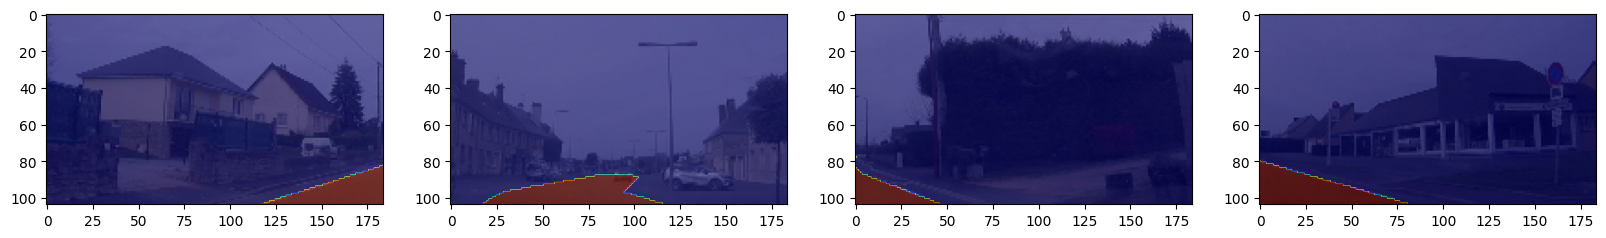

In [391]:
fig, ax = plt.subplots(ncols=4, figsize=(20,20))
for idx in range(4):
    image=res[0][idx]
    mask=res[1][idx]
    ax[idx].imshow(image)
    ax[idx].imshow(mask, cmap='jet', alpha=0.5)
plt.show()

## Création du Model

In [392]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, Conv3D, Dense, GlobalMaxPooling2D, GlobalMaxPooling3D, UpSampling2D, MaxPool2D, MaxPooling2D, Dropout, Concatenate

In [393]:
def build_model():
    input_shape = (104, 184, 3)

    # Define the input layer
    inputs = Input(input_shape)

    # Encoder
    conv1 = Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    conv1 = Conv2D(32, (3, 3), activation='relu', padding='same')(conv1)
    pool1 = MaxPooling2D((2, 2))(conv1)

    conv2 = Conv2D(64, (3, 3), activation='relu', padding='same')(pool1)
    conv2 = Conv2D(64, (3, 3), activation='relu', padding='same')(conv2)
    pool2 = MaxPooling2D((2, 2))(conv2)

    conv3 = Conv2D(128, (3, 3), activation='relu', padding='same')(pool2)
    conv3 = Conv2D(128, (3, 3), activation='relu', padding='same')(conv3)
    pool3 = MaxPooling2D((2, 2))(conv3)

    # Bridge
    conv4 = Conv2D(256, (3, 3), activation='relu', padding='same')(pool3)
    conv4 = Conv2D(256, (3, 3), activation='relu', padding='same')(conv4)
    drop4 = Dropout(0.5)(conv4)

    # Decoder
    up5 = UpSampling2D((2, 2))(drop4)
    up5 = Conv2D(128, (3, 3), activation='relu', padding='same')(up5)
    concat5 = Concatenate()([conv3, up5])

    conv5 = Conv2D(128, (3, 3), activation='relu', padding='same')(concat5)
    conv5 = Conv2D(128, (3, 3), activation='relu', padding='same')(conv5)
    up6 = UpSampling2D((2, 2))(conv5)
    up6 = Conv2D(64, (3, 3), activation='relu', padding='same')(up6)
    concat6 = Concatenate()([conv2, up6])

    conv6 = Conv2D(64, (3, 3), activation='relu', padding='same')(concat6)
    conv6 = Conv2D(64, (3, 3), activation='relu', padding='same')(conv6)
    up7 = UpSampling2D((2, 2))(conv6)
    up7 = Conv2D(32, (3, 3), activation='relu', padding='same')(up7)
    concat7 = Concatenate()([conv1, up7])

    conv7 = Conv2D(32, (3, 3), activation='relu', padding='same')(concat7)
    conv7 = Conv2D(32, (3, 3), activation='relu', padding='same')(conv7)

    # Output layer
    output = Conv2D(1, (1, 1), activation='sigmoid')(conv7)
    
    # Create the model
    model = Model(inputs=inputs, outputs=output)
    return model

In [394]:
roadmodel = build_model()

In [395]:
roadmodel.summary()

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_2 (InputLayer)           [(None, 104, 184, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d_18 (Conv2D)             (None, 104, 184, 32  896         ['input_2[0][0]']                
                                )                                                                 
                                                                                                  
 conv2d_19 (Conv2D)             (None, 104, 184, 32  9248        ['conv2d_18[0][0]']              
                                )                                                           

In [413]:
X, Y = train.as_numpy_iterator().next()

In [414]:
masks = roadmodel.predict(X)

1/1 [==============================] - 0s 198ms/step


## Pertes et Optimisations

In [415]:
from tensorflow.keras.optimizers.legacy import Adam

In [416]:
batches_per_epoch = len(train)
lr_decay = (1./0.75 -1)/batches_per_epoch

In [417]:
optimizer = Adam(learning_rate=0.0001, decay=lr_decay)

In [418]:
loss_fn = tf.keras.losses.BinaryCrossentropy()

In [419]:
loss_fn(Y, masks).numpy()

0.68518406

## Entrainement

In [421]:
roadmodel.compile(optimizer=optimizer, loss=loss_fn, metrics=['accuracy'])

In [422]:
logdir='logs'

In [423]:
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=logdir)

In [424]:
hist = roadmodel.fit(train, epochs=40, validation_data=val, callbacks=[tensorboard_callback])

Epoch 1/40
68/68 [==============================] - 67s 970ms/step - loss: 0.3527 - accuracy: 0.8881 - val_loss: 0.1901 - val_accuracy: 0.8829
Epoch 2/40
68/68 [==============================] - 66s 974ms/step - loss: 0.1658 - accuracy: 0.8982 - val_loss: 0.1813 - val_accuracy: 0.9302
Epoch 3/40
68/68 [==============================] - 66s 969ms/step - loss: 0.1417 - accuracy: 0.9396 - val_loss: 0.1422 - val_accuracy: 0.9432
Epoch 4/40
68/68 [==============================] - 68s 993ms/step - loss: 0.1168 - accuracy: 0.9519 - val_loss: 0.1347 - val_accuracy: 0.9475
Epoch 5/40
68/68 [==============================] - 68s 994ms/step - loss: 0.1064 - accuracy: 0.9568 - val_loss: 0.1343 - val_accuracy: 0.9489
Epoch 6/40
68/68 [==============================] - 67s 979ms/step - loss: 0.0971 - accuracy: 0.9608 - val_loss: 0.1215 - val_accuracy: 0.9516
Epoch 7/40
68/68 [==============================] - 66s 964ms/step - loss: 0.0936 - accuracy: 0.9617 - val_loss: 0.1210 - val_accuracy: 0.9515

In [425]:
roadmodel.save('final.h5')

In [426]:
hist.history

{'loss': [0.35270923376083374,
  0.1658031940460205,
  0.14170068502426147,
  0.11678440123796463,
  0.10635368525981903,
  0.09705021232366562,
  0.09358526766300201,
  0.08748907595872879,
  0.08637812733650208,
  0.08525637537240982,
  0.08042269945144653,
  0.07731486856937408,
  0.07548605650663376,
  0.0729435533285141,
  0.07074187695980072,
  0.07006186991930008,
  0.06738189607858658,
  0.06627478450536728,
  0.0657668486237526,
  0.06374093145132065,
  0.06455525010824203,
  0.06236632913351059,
  0.06078248843550682,
  0.05941081792116165,
  0.059145692735910416,
  0.058117978274822235,
  0.05755646899342537,
  0.05650677531957626,
  0.05572844296693802,
  0.055176056921482086,
  0.05504929646849632,
  0.053699348121881485,
  0.053839363157749176,
  0.05275740101933479,
  0.05263850837945938,
  0.0518869124352932,
  0.051886092871427536,
  0.051440220326185226,
  0.05062941461801529,
  0.04953722283244133],
 'accuracy': [0.888066291809082,
  0.8981751799583435,
  0.939634323

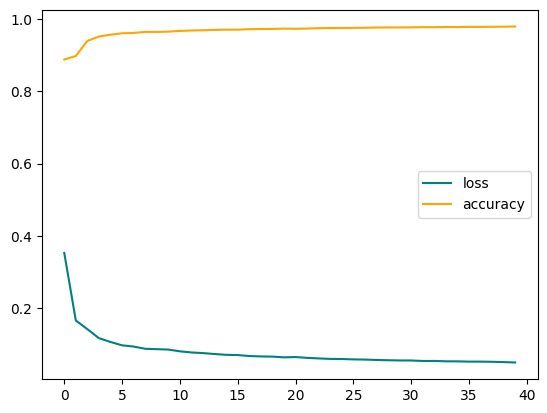

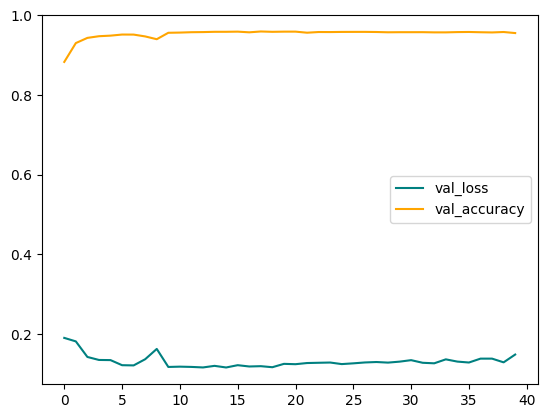

In [469]:
plt.figure(0)
plt.plot(hist.history['loss'], color='teal', label='loss')
plt.plot(hist.history['accuracy'], color='orange', label='accuracy')
plt.legend()
plt.show()
plt.figure(1)
plt.plot(hist.history['val_loss'], color="teal", label="val_loss")
plt.plot(hist.history['val_accuracy'], color="orange", label="val_accuracy")
plt.legend()

In [465]:
test_sample = test.as_numpy_iterator().next() 

In [466]:
yhat = roadmodel.predict(test_sample[0])

1/1 [==============================] - 0s 206ms/step


In [467]:
yhat.shape

(8, 104, 184, 1)

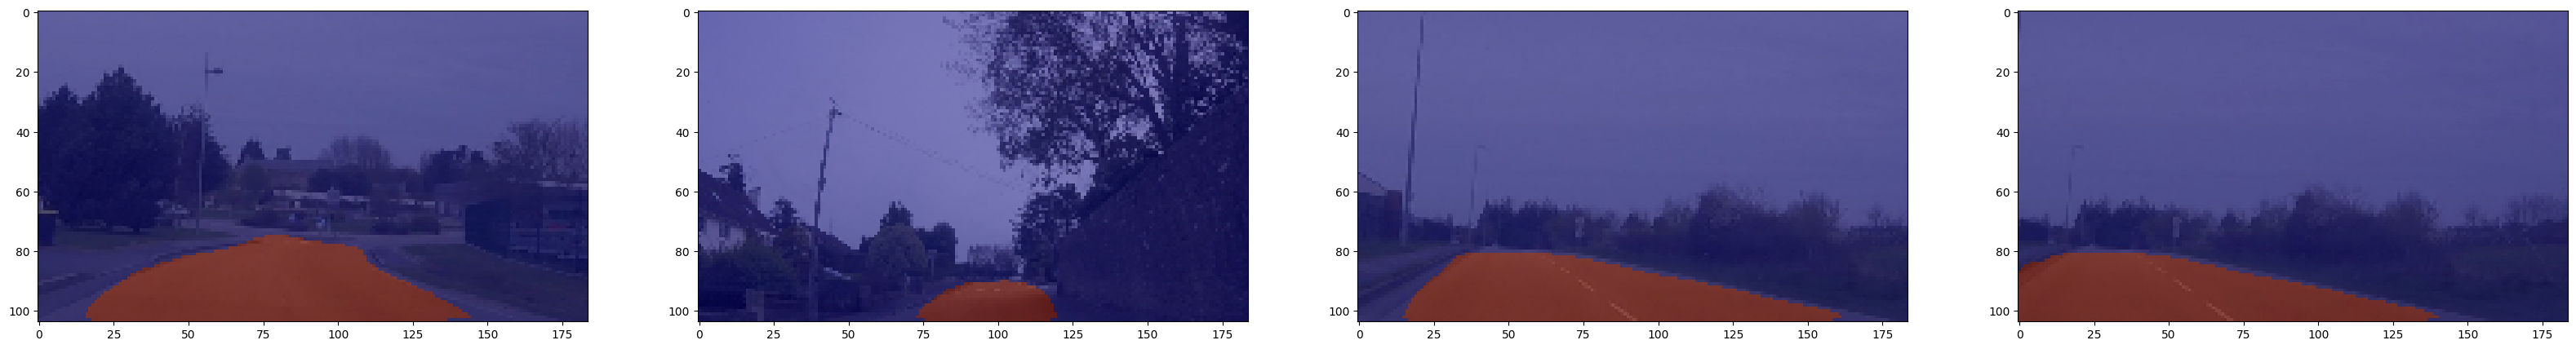

In [468]:
fig, ax = plt.subplots(ncols=4, figsize=(40,20))
for idx in range(4):
    image=test_sample[0][idx]
    mask=yhat[idx]
    ax[idx].imshow(image)
    ax[idx].imshow(np.round(mask), cmap='jet', alpha=0.5)
plt.show()